Fetching MNIST dataset...
Dataset loaded. Shape: (70000, 784)

Starting PCA...
PCA completed in 0.34 seconds.

Starting t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed in 92.96 seconds.

Generating visualizations...


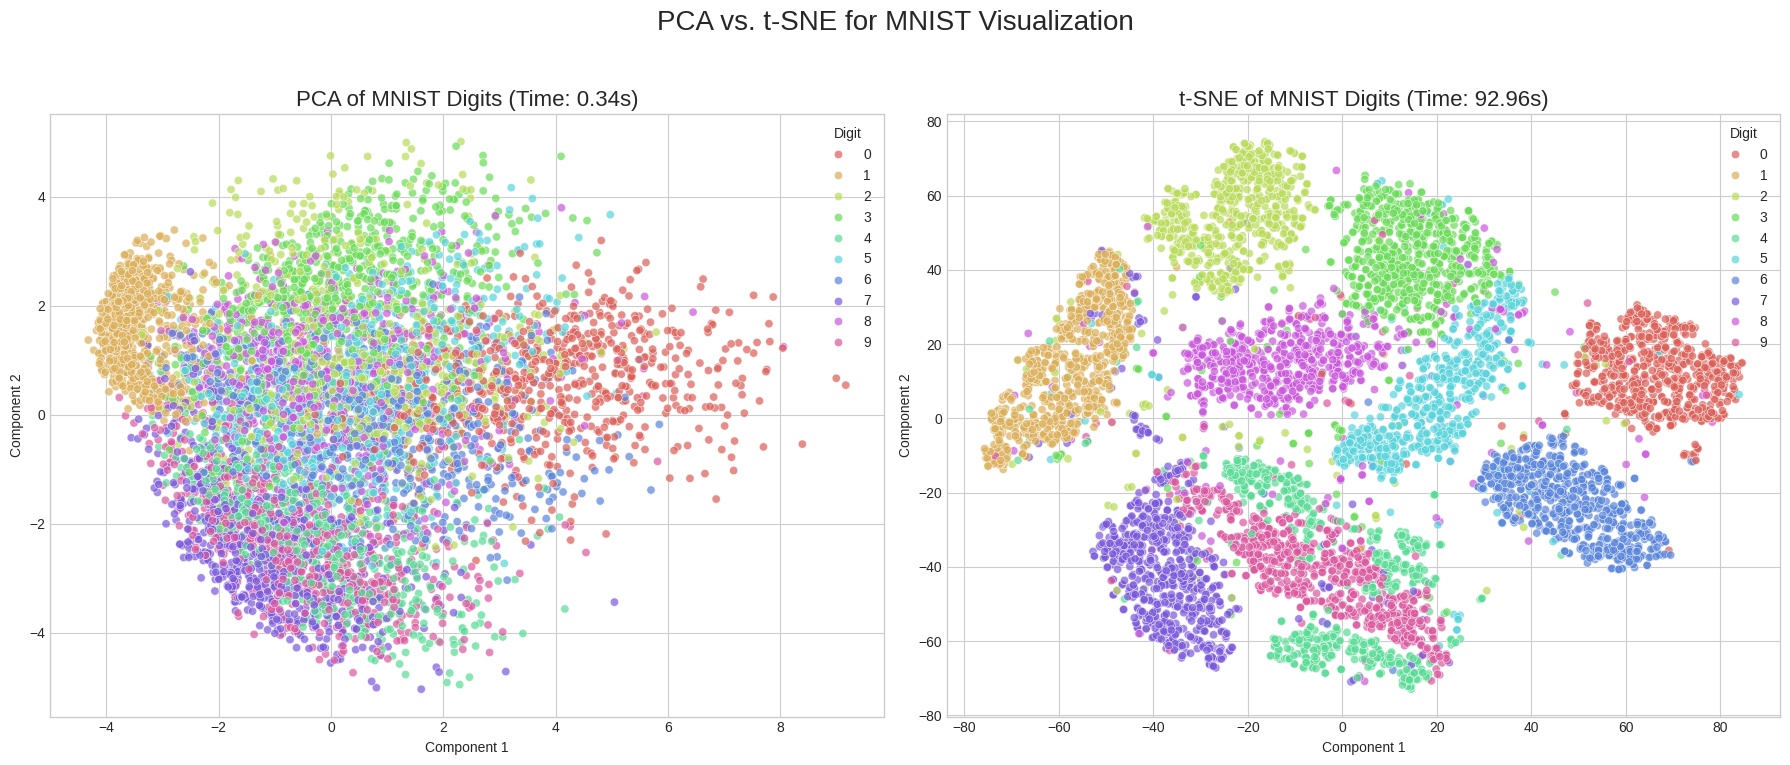

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_reduction(X_reduced, y, title):
    """
    Helper function to create a scatter plot of reduced-dimension data.

    Args:
        X_reduced (np.array): The 2D data after dimensionality reduction.
        y (np.array): The labels for the data points.
        title (str): The title for the plot.
    """
    df = pd.DataFrame({
        'component_1': X_reduced[:, 0],
        'component_2': X_reduced[:, 1],
        'label': y.astype(int)
    })

    sns.scatterplot(
        x='component_1',
        y='component_2',
        hue='label',
        palette=sns.color_palette("hls", 10),
        data=df,
        legend="full",
        alpha=0.7
    )
    plt.title(title, fontsize=16)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title='Digit')

def main():
    """
    Main function to load data, apply PCA and t-SNE, and visualize results.
    """
    print("Fetching MNIST dataset...")
    # Using fetch_openml to get the MNIST dataset (70,000 images)
    # The 'parser' argument is set to 'auto' to avoid a future warning.
    mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')
    X = mnist.data.astype('float32')
    y = mnist.target.astype('int64')

    print("Dataset loaded. Shape:", X.shape)

    # --- Data Subsetting and Preprocessing ---
    # t-SNE is computationally expensive, so we'll use a subset of the data.
    # We create a random permutation and select the first N samples.
    N = 7000
    np.random.seed(42)
    rndperm = np.random.permutation(X.shape[0])
    X_subset = X.iloc[rndperm[:N]]
    y_subset = y.iloc[rndperm[:N]]

    # Normalize pixel values to be between 0 and 1
    X_subset = X_subset / 255.0

    # --- PCA (Principal Component Analysis) ---
    print("\nStarting PCA...")
    time_start_pca = time.time()

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_subset)

    pca_time = time.time() - time_start_pca
    print(f"PCA completed in {pca_time:.2f} seconds.")

    # --- t-SNE (t-Distributed Stochastic Neighbor Embedding) ---
    print("\nStarting t-SNE...")
    time_start_tsne = time.time()

    # Best practice for t-SNE is to use PCA for initial reduction, but here we
    # apply it to the original data for a clearer comparison.
    # learning_rate='auto' and init='pca' are modern defaults.
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        n_iter=1000,
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_subset)

    tsne_time = time.time() - time_start_tsne
    print(f"t-SNE completed in {tsne_time:.2f} seconds.")

    # --- Visualization ---
    print("\nGenerating visualizations...")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Plot PCA
    plt.sca(axes[0])
    visualize_reduction(X_pca, y_subset, f'PCA of MNIST Digits (Time: {pca_time:.2f}s)')

    # Plot t-SNE
    plt.sca(axes[1])
    visualize_reduction(X_tsne, y_subset, f't-SNE of MNIST Digits (Time: {tsne_time:.2f}s)')

    plt.suptitle("PCA vs. t-SNE for MNIST Visualization", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


if __name__ == '__main__':
    main()
